In [1]:
def preprocess_ton_iot(dataset_dir, samples_per_file, seed):
    # TON_IoT files are standard CSVs with headers
    csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))
    mini_batches = []
    
    print(f"Loading {len(csv_files)} data files...")
    for f in csv_files:
        try:
            # low_memory=False to prevent warnings on high-cardinality string columns
            df_chunk = pd.read_csv(f, low_memory=False)
            df_chunk.columns = df_chunk.columns.str.strip()
            
            if len(df_chunk) > samples_per_file:
                df_chunk = df_chunk.sample(n=samples_per_file, random_state=seed)
            mini_batches.append(df_chunk)
            del df_chunk 
            gc.collect()
        except Exception as e:
            print(f"Skipping {f}: {e}")

    if not mini_batches:
        raise ValueError("No data loaded. Please check the DATASET_DIR path.")
        
    data = pd.concat(mini_batches, ignore_index=True)

    # 1. Drop IPs to prevent spatial overfitting and drop the binary label
    data = data.drop(columns=['src_ip', 'dst_ip', 'label'], errors='ignore')

    # 2. Prepare X and y
    y_raw = data['type'].astype(str).str.strip().values
    X_df = data.drop(columns=['type'], errors='ignore')

    # 3. Categorical encoding for all string/object columns
    # We dynamically select all object types so we don't have to hardcode all 25 names
    cat_columns = X_df.select_dtypes(include=['object']).columns
    
    print(f"\nEncoding {len(cat_columns)} categorical features...")
    for col in cat_columns:
        if col in X_df.columns:
            # Force everything to string. The '-' will safely encode to an integer.
            X_df[col] = X_df[col].astype(str).str.strip()
            le_col = LabelEncoder()
            X_df[col] = le_col.fit_transform(X_df[col])

    # 4. Convert to numeric array and clip massive outliers
    X_raw = X_df.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy()
    X_raw = np.clip(X_raw, -1e6, 1e6)

    # 5. Encode target labels (10 distinct classes)
    le_target = LabelEncoder()
    y_all = le_target.fit_transform(y_raw)
    
    output_dim = len(le_target.classes_)
    input_dim = X_raw.shape[1]
    
    print(f"\n--- Target Class Distribution ---")
    unique, counts = np.unique(y_raw, return_counts=True)
    for u, c in zip(unique, counts): 
        print(f"{u}: {c}")
    
    return X_raw, y_all, input_dim, output_dim, le_target.classes_

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import tenseal as ts
import gc

SEED = 42
BATCH_SIZE = 128
NUM_CLIENTS = 6
PUBLIC_DATA_RATIO = 0.05 
VAL_SIZE = 0.1
ROUNDS = 5
LOCAL_EPOCHS = 3 
TEMPERATURE = 3.0       

torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
# Provide the exact folder path where train_test_network.csv lives
DATASET_DIR = r"C:\Users\SREENITHI\Downloads\Train_Test_Network_dataset\Train_Test_Network_dataset" 
SAMPLES_PER_FILE = 250000# 

X_raw, y_all, INPUT_DIM, OUTPUT_DIM, class_names = preprocess_ton_iot(
    dataset_dir=DATASET_DIR, 
    samples_per_file=SAMPLES_PER_FILE, 
    seed=SEED
)

print(f"\nPreprocessing Complete. Input Dim: {INPUT_DIM}, Output Dim: {OUTPUT_DIM}")
print(f"Classes: {class_names}")


Loading 1 data files...

Encoding 24 categorical features...

--- Target Class Distribution ---
backdoor: 20000
ddos: 20000
dos: 20000
injection: 20000
mitm: 1043
normal: 50000
password: 20000
ransomware: 20000
scanning: 20000
xss: 20000

Preprocessing Complete. Input Dim: 40, Output Dim: 10
Classes: ['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']



 Client Data Allocation
Client 0: 38103 Train samples, 4234 Val samples
Client 1: 21962 Train samples, 2441 Val samples
Client 2: 30253 Train samples, 3362 Val samples
Client 3: 19139 Train samples, 2127 Val samples
Client 4: 22165 Train samples, 2463 Val samples
Client 5: 21750 Train samples, 2417 Val samples

 Federated Learning Experiment
Clients: 6 | Rounds: 5 | Local Epochs: 3
Aggregation: weighted; Distillation temperature: 3.0
Privacy: CKKS homomorphic encryption (No Differential Privacy)

Round 1 Aggregation Weights: ['0.248', '0.143', '0.197', '0.125', '0.145', '0.142']
Round 1 Statistics
Client 0: [Train] Acc 0.8933 | [Val] Acc 0.8918
Client 1: [Train] Acc 0.8720 | [Val] Acc 0.8681
Client 2: [Train] Acc 0.8872 | [Val] Acc 0.8864
Client 3: [Train] Acc 0.8139 | [Val] Acc 0.8119
Client 4: [Train] Acc 0.7428 | [Val] Acc 0.7511
Client 5: [Train] Acc 0.8164 | [Val] Acc 0.8109

Round 2 Aggregation Weights: ['0.178', '0.173', '0.177', '0.162', '0.150', '0.162']
Round 2 Statistics
Cl

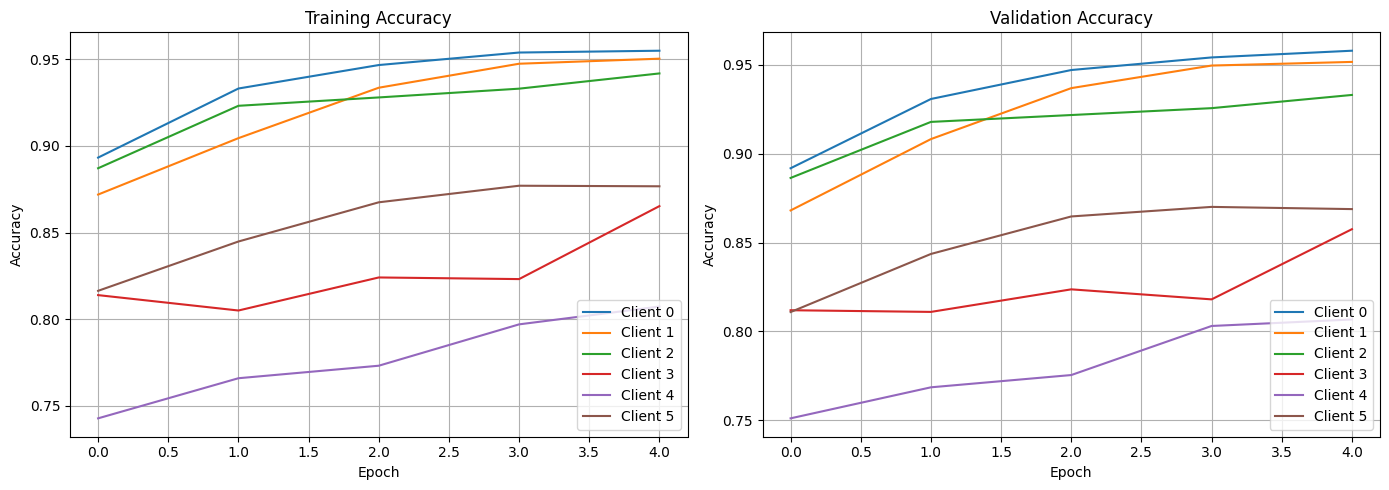

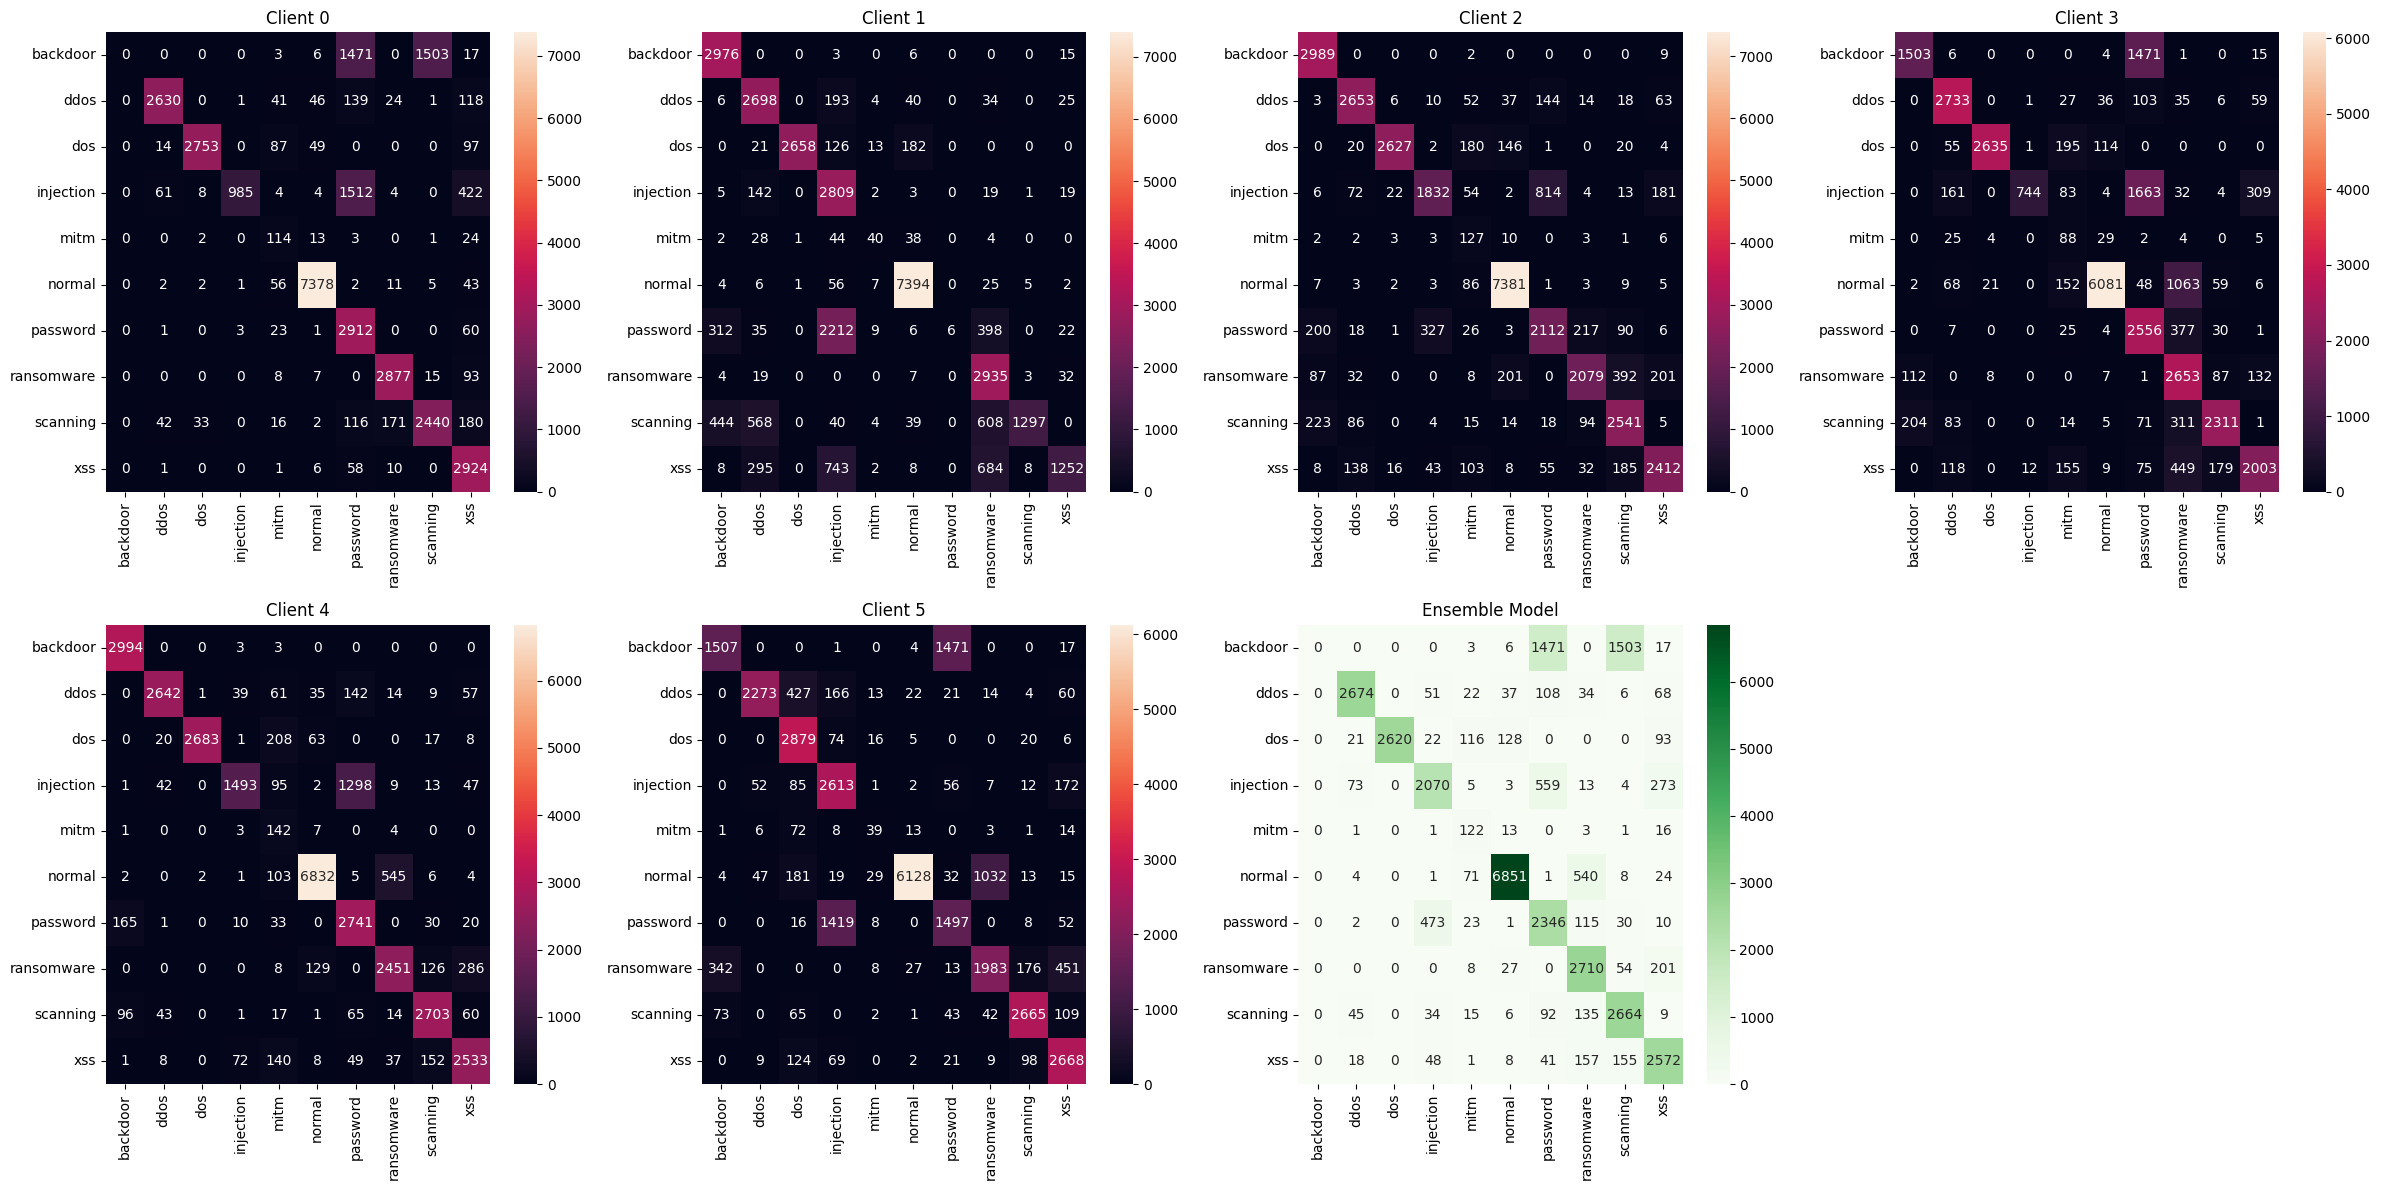

In [4]:
X_train_full, X_test_global, y_train_full, y_test_global = train_test_split(
    X_raw, y_all, test_size=0.15, stratify=y_all, random_state=SEED
)

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test_global = scaler.transform(X_test_global) 

X_train_private, X_public, y_train_private, y_public = train_test_split(
    X_train_full, y_train_full, test_size=PUBLIC_DATA_RATIO, stratify=y_train_full, random_state=SEED
)
X_public_tensor = torch.tensor(X_public, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_global, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_global, dtype=torch.long)


def prepare_clients(X, y, num_clients=5, alpha=0.5):
    idx_by_label = {lbl: np.where(y == lbl)[0] for lbl in np.unique(y)}
    client_indices = {i: [] for i in range(num_clients)}
    for lbl, idxs in idx_by_label.items():
        np.random.shuffle(idxs)
        proportions = (np.random.dirichlet([alpha] * num_clients) * len(idxs)).astype(int)
        while proportions.sum() < len(idxs): 
            proportions[np.argmax(proportions)] += 1
        start = 0
        for cid, cnt in enumerate(proportions):
            client_indices[cid].extend(idxs[start:start + cnt])
            start += cnt

    clients_data = []
    print("\n Client Data Allocation")
    for cid in range(num_clients):
        idxs = client_indices[cid]
        tr_idx, val_idx = train_test_split(idxs, test_size=VAL_SIZE, random_state=SEED)
        clients_data.append({
            'train': (torch.tensor(X[tr_idx], dtype=torch.float32), torch.tensor(y[tr_idx], dtype=torch.long)),
            'val': (torch.tensor(X[val_idx], dtype=torch.float32), torch.tensor(y[val_idx], dtype=torch.long)),
            'n_samples': len(tr_idx)
        })
        print(f"Client {cid}: {len(tr_idx)} Train samples, {len(val_idx)} Val samples")
    return clients_data

clients = prepare_clients(X_train_private, y_train_private, num_clients=NUM_CLIENTS)
TOTAL_TRAIN_SAMPLES = sum(c['n_samples'] for c in clients)

context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
context.generate_galois_keys()
context.global_scale = 2**40


class Client0_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM, 512), nn.ReLU(), nn.Linear(512, OUTPUT_DIM))
    def forward(self, x): 
        return self.net(x)


class Client1_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM, 256), nn.ReLU(), nn.Linear(256, OUTPUT_DIM))
    def forward(self, x): 
        return self.net(x)


class Client2_ResMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, 256)
        self.fc2 = nn.Linear(256, OUTPUT_DIM)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class Client3_BiGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, OUTPUT_DIM)
    def forward(self, x):
        _, h = self.gru(x.unsqueeze(-1))
        return self.fc(torch.cat((h[-2], h[-1]), dim=1))


class Client4_TabAttention(nn.Module):
    def __init__(self, input_dim, output_dim, n_heads=4, embed_dim=32):
        super().__init__()
        self.feature_embed = nn.Linear(1, embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True)
        self.ln = nn.LayerNorm(embed_dim)
        self.fc = nn.Sequential(
            nn.Linear(input_dim * embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.feature_embed(x)
        attn_out, _ = self.attention(x, x, x)
        x = self.ln(x + attn_out)
        x = x.view(x.size(0), -1)
        return self.fc(x)



class Client5_CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.flattened_size = 32 * INPUT_DIM
        
        self.fc1 = nn.Linear(self.flattened_size, 64)
        self.fc2 = nn.Linear(64, OUTPUT_DIM)
        
    def forward(self, x):
        x = x.unsqueeze(1) 
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        return self.fc2(x)


models = {
    0: Client0_MLP(), 
    1: Client1_MLP(), 
    2: Client2_ResMLP(), 
    3: Client3_BiGRU(), 
    4: Client4_TabAttention(INPUT_DIM, OUTPUT_DIM),
    5: Client5_CNN1D()
}

optimizers = {cid: optim.Adam(models[cid].parameters(), lr=1e-3) for cid in range(NUM_CLIENTS)}

history_val = {cid: [] for cid in range(NUM_CLIENTS)}
history_train = {cid: [] for cid in range(NUM_CLIENTS)}
client_accuracies = {cid: 0.0 for cid in range(NUM_CLIENTS)}


def get_metrics(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X), dim=1).cpu().numpy()
        y_true = y.cpu().numpy()
    return accuracy_score(y_true, preds), f1_score(y_true, preds, average="weighted")


def local_train_and_encrypt(cid, aggregation_weight):
    model, opt = models[cid], optimizers[cid]
    Xc, yc = clients[cid]['train']
    
    class_counts = torch.bincount(yc, minlength=OUTPUT_DIM).float()
    total_samples = len(yc)
    class_weights = total_samples / (len(class_counts) * (class_counts + 10))
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    class_weights = torch.clamp(class_weights, min=0.1, max=20.0)
    
    model.train()
    for epoch in range(LOCAL_EPOCHS):
        for i in range(0, len(Xc), BATCH_SIZE):
            opt.zero_grad()
            batch_X = Xc[i:i+BATCH_SIZE]
            batch_y = yc[i:i+BATCH_SIZE]
            
            outputs = model(batch_X)
            loss = F.cross_entropy(outputs, batch_y, weight=class_weights)
            loss.backward()
            opt.step()
            
    model.eval()
    with torch.no_grad():
        avg_logits = model(X_public_tensor).mean(dim=0).cpu().numpy()
    
    return ts.ckks_vector(context, avg_logits * aggregation_weight)


def server_aggregate(encrypted_list):
    agg = encrypted_list[0]
    for i in range(1, len(encrypted_list)):
        agg += encrypted_list[i]
    return agg


def client_decryption_and_distill(cid, encrypted_global_vec):
    global_logits_plaintext = encrypted_global_vec.decrypt() 
    target_logits = torch.tensor(global_logits_plaintext, dtype=torch.float32)
    
    model, opt = models[cid], optimizers[cid]
    model.train()
    opt.zero_grad()
    
    student_logits = model(X_public_tensor).mean(dim=0)
    T = TEMPERATURE
    
    loss = nn.KLDivLoss(reduction="batchmean")(
        F.log_softmax(student_logits.unsqueeze(0) / T, dim=1),
        F.softmax(target_logits.unsqueeze(0) / T, dim=1)
    ) * (T * T)
    
    loss.backward()
    opt.step()


print("\n Federated Learning Experiment")
print(f"Clients: {NUM_CLIENTS} | Rounds: {ROUNDS} | Local Epochs: {LOCAL_EPOCHS}")
print(f"Aggregation: weighted; Distillation temperature: {TEMPERATURE}")
print("Privacy: CKKS homomorphic encryption (No Differential Privacy)")


for r in range(ROUNDS):
    if r == 0:
        raw_weights = [clients[cid]['n_samples'] for cid in range(NUM_CLIENTS)]
    else:
        raw_weights = [client_accuracies[cid] + 1e-4 for cid in range(NUM_CLIENTS)]
    
    total_w = sum(raw_weights)
    norm_weights = [w / total_w for w in raw_weights]
    
    print(f"\nRound {r+1} Aggregation Weights: {[f'{w:.3f}' for w in norm_weights]}")

    ciphertexts = [local_train_and_encrypt(cid, norm_weights[cid]) for cid in range(NUM_CLIENTS)]
    encrypted_global = server_aggregate(ciphertexts)
    
    for cid in range(NUM_CLIENTS):
        client_decryption_and_distill(cid, encrypted_global)

    print(f"Round {r+1} Statistics")
    for cid in range(NUM_CLIENTS):
        t_acc, _ = get_metrics(models[cid], clients[cid]['train'][0], clients[cid]['train'][1])
        v_acc, _ = get_metrics(models[cid], clients[cid]['val'][0], clients[cid]['val'][1])
        history_train[cid].append(t_acc)
        history_val[cid].append(v_acc)
        client_accuracies[cid] = v_acc
        print(f"Client {cid}: [Train] Acc {t_acc:.4f} | [Val] Acc {v_acc:.4f}")


def ensemble_predict(models, X):
    logits_sum = None
    with torch.no_grad():
        for cid, model in models.items():
            model.eval()
            logits = model(X)
            if logits_sum is None:
                logits_sum = logits
            else:
                logits_sum += logits
        avg_logits = logits_sum / len(models)
        y_pred = torch.argmax(avg_logits, dim=1)
    return y_pred.cpu().numpy()


y_pred_ens = ensemble_predict(models, X_test_tensor)

ens_acc = accuracy_score(y_test_global, y_pred_ens)
ens_f1 = f1_score(y_test_global, y_pred_ens, average="weighted")

print("\n Global Ensemble Performance")
print(f"Ensemble Accuracy: {ens_acc:.4f}")
print(f"Ensemble F1-score: {ens_f1:.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i in range(NUM_CLIENTS):
    plt.plot(history_train[i], label=f'Client {i}')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for i in range(NUM_CLIENTS):
    plt.plot(history_val[i], label=f'Client {i}')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(24, 12)) 
axes = axes.flatten()

for cid in range(NUM_CLIENTS):
    y_pred = torch.argmax(models[cid](X_test_tensor), dim=1).cpu().numpy()
    sns.heatmap(
        confusion_matrix(y_test_global, y_pred),
        annot=True,
        fmt='d',
        ax=axes[cid],
        xticklabels=class_names,
        yticklabels=class_names
    )
    axes[cid].set_title(f'Client {cid}')

sns.heatmap(
    confusion_matrix(y_test_global, y_pred_ens),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[6], 
    xticklabels=class_names,
    yticklabels=class_names
)
axes[6].set_title('Ensemble Model')
axes[7].axis('off')

plt.tight_layout()
plt.show()


In [5]:
print("\n Final Client-wise Performance ")
for cid in range(NUM_CLIENTS):
    acc, f1 = get_metrics(models[cid], X_test_tensor, y_test_tensor)
    print(f"Client {cid} ({models[cid].__class__.__name__}): Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")


 Final Client-wise Performance 
Client 0 (Client0_MLP): Test Acc = 0.7901, Test F1 = 0.7537
Client 1 (Client1_MLP): Test Acc = 0.7602, Test F1 = 0.7209
Client 2 (Client2_ResMLP): Test Acc = 0.8451, Test F1 = 0.8465
Client 3 (Client3_BiGRU): Test Acc = 0.7362, Test F1 = 0.7405
Client 4 (Client4_TabAttention): Test Acc = 0.8597, Test F1 = 0.8639
Client 5 (Client5_CNN1D): Test Acc = 0.7661, Test F1 = 0.7672
